# Bivariate Global Maps of Front-Associated Properties

Loads the co-located output from **`build_v4`** and creates bivariate global
maps where each front is colored by **two properties** simultaneously.

The notebook is organised so that almost every choice lives in a clearly
marked configuration cell:

1. **Configure** — data paths, available variables + display labels
2. **Data Loading** — load the co-located tables (+ a temporary `coriolis_f`
   loader from `build_v3`)
3. **Derived Variables** — quantities computed from loaded columns
   (e.g. `divergence_over_f`)
4. **Variable Selection** — pick `VAR1`, `VAR2`, `DEPTH_LEVEL`,
   `SUMMARY_STATISTIC`, plus a diagnostic to help choose bin ranges
5. **Plot Configuration** — bins, bin ranges, colors
6. **Plotting Functions** — `plot_bivariate_legend`,
   `plot_global_binned_map`, `plot_global_scatter_map`

Data are produced by `fronts/runs/prototypes/one_full/build_v4.py`.

---
## 1. Configure

### 1a. Data paths

User-configurable paths for the `build_v4` co-located outputs.

In [49]:
import os
from pathlib import Path

# ─── build_v4 CO-LOCATED OUTPUT ───────────────────────────────────────────────
# Root of the OGCM data tree (must contain LLC/Fronts/...)
OGCM_ROOT = os.environ.get('OS_OGCM', '/mnt/tank/Oceanography/data/OGCM')

# build_v4 co-located output directory.
# Standard layout: $OS_OGCM/LLC/Fronts/<RUN_ID>/<YYYYMMDD_HHMMSS>/
RESULTS_DIR = Path(OGCM_ROOT) / 'LLC' / 'Fronts' / 'V4' / '20121109_120000'

# Snapshot timestamp (ISO 8601, used by viz_loaders).
TIME_STR = '2012-11-09T12:00:00'

# Run tag (suffix on output filenames). For build_v4 this is the run_id.
RUN_TAG = 'V4_bin_D'

# LLC coordinate file (None -> $OS_OGCM/LLC/Fronts/coords/LLC_coords_lat_lon.nc)
COORDS_FILE = None

### 1b. Available variables and display labels

`VARIABLE_LABELS` maps each base variable name (taken from
`build_v4.py`'s `PROPERTY_ROOTS`) to a display label used for axis titles.

**Depth is configured separately** (see §4), so these labels do **not**
include depth suffixes such as `sfc`, `25m`, `mld`, or `mld_mean`.

`DEPTH_SUFFIXES` maps the user-facing depth level to the suffix actually used
in the co-located column names. `build_v4` writes depth-expanded channels with
the suffixes `[sfc, z25m, mld, mld_mean]`, so the user-friendly `"25m"` maps to
the on-disk `"z25m"`.

In [50]:
# ─── DISPLAY LABELS FOR EACH BASE VARIABLE ────────────────────────────────────
# Keys are the build_v4 PROPERTY_ROOTS (no depth suffix, no statistic suffix).
VARIABLE_LABELS = {
    # stratification / mixing
    "N2":                       r"$N^2$ (buoyancy freq.)",
    "vertical_shear":           "Vertical shear",
    "Ri":                       r"$Ri$ (Richardson)",
    "Fr":                       r"$Fr$ (Froude)",
    "Ro":                       r"$Ro$ (Rossby)",
    "Bu":                       r"$Bu$ (Burger)",
    # potential vorticity
    "ertel_pv":                 "Ertel PV",
    "ertel_pv_vertical":        "Ertel PV (vertical)",
    "ertel_pv_tilt":            "Ertel PV (tilt)",
    # buoyancy fluxes
    "uB":                       r"$u'b'$",
    "vB":                       r"$v'b'$",
    "wB":                       r"$w'b'$",
    # energetics
    "KE":                       "Kinetic energy",
    # frontal structure
    "gradb2":                   r"$|\nabla b|^2$",
    "gradtheta2":               r"$|\nabla \Theta|^2$",
    "gradsalt2":                r"$|\nabla S|^2$",
    "gradrho2":                 r"$|\nabla \rho|^2$",
    "gradeta2":                 r"$|\nabla \eta|^2$",
    "turner_angle":             "Turner angle",
    # kinematic
    "relative_vorticity":       r"$\zeta$ (rel. vorticity)",
    "strain_n":                 "Normal strain",
    "strain_s":                 "Shear strain",
    "strain_mag":               "Strain magnitude",
    "divergence":               r"$\delta$ (divergence)",
    "okubo_weiss":              "Okubo-Weiss",
    "coriolis_f":               r"$f$ (Coriolis)",
    # frontogenesis
    "frontogenesis_tendency":   "Frontogenesis tendency",
    "frontogenesis_geo":        "Frontogenesis (geo.)",
    "frontogenesis_ageo":       "Frontogenesis (ageo.)",
    "ug":                       r"$u_g$ (geostrophic)",
    "vg":                       r"$v_g$ (geostrophic)",
    # native fields
    "Theta":                    r"$\Theta$ (pot. temp.)",
    "Salt":                     "Salinity",
    "Eta":                      r"$\eta$ (SSH)",
    "U":                        r"$U$",
    "V":                        r"$V$",
    "W":                        r"$W$",
    # surface-only / bare (depth level is ignored for these)
    "mixed_layer_depth":        "Mixed layer depth",
    "ml_heat_content":          "ML heat content",
    "oceTAUX":                  r"$\tau_x$ (wind stress)",
    "oceTAUY":                  r"$\tau_y$ (wind stress)",
    "oceQnet":                  "Net heat flux",
    "wind_stress_curl":         "Wind stress curl",
    "ekman_pumping":            "Ekman pumping",
    "SIarea":                   "Sea-ice area",
}

# ─── DEPTH LEVEL -> COLUMN SUFFIX ─────────────────────────────────────────────
# User-facing depth level  ->  suffix used in the co-located column names.
DEPTH_SUFFIXES = {
    "sfc":      "sfc",
    "25m":      "z25m",     # build_v4 stores the 25 m level as 'z25m'
    "mld":      "mld",
    "mld_mean": "mld_mean",
}

---
## 2. Data Loading

In [51]:
import sys
import numpy as np
import pandas as pd

# Ensure the fronts package is importable
from fronts.properties.viz_loaders import (
    load_global_front_results,
    load_colocation_table,
    load_geometry_table,
    merge_geometry_colocation,
)

In [52]:
# Load all front results (geometry + colocation merged, coords aligned)
results = load_global_front_results(
    results_dir=RESULTS_DIR,
    time_str=TIME_STR,
    run_tag=RUN_TAG,
    coords_file=COORDS_FILE,
)

df_enriched    = results['df_enriched']
lat_global     = results['lat_global']
lon_global     = results['lon_global']
labeled_global = results['labeled_global']
metadata       = results['metadata']

print(f"Enriched DataFrame: {df_enriched.shape[0]:,} fronts, {df_enriched.shape[1]} columns")
print(f"Grid shape: {lat_global.shape}")

Loading metadata from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V4/20121109_120000/metadata_20121109T12_00_00_V4_bin_D.json
Loading geometry table from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V4/20121109_120000/global_front_geometry_20121109T12_00_00_V4_bin_D.parquet
Loading colocation table from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V4/20121109_120000/front_properties_20121109T12_00_00_V4_bin_D.parquet
Enriched DataFrame: 112,542 fronts, 639 columns
Grid shape: (12960, 17280)


In [53]:
# ─── INSPECT AVAILABLE COLUMNS ────────────────────────────────────────────────
# Print all columns so we can verify the variable names exist.
print("All columns in df_enriched:")
print("-" * 50)
for col in sorted(df_enriched.columns):
    print(f"  {col}")
print(f"\nTotal: {len(df_enriched.columns)} columns")

All columns in df_enriched:
--------------------------------------------------
  Bu_mld_mean
  Bu_mld_mean_mean
  Bu_mld_mean_median
  Bu_mld_mean_p25
  Bu_mld_mean_p75
  Bu_mld_mean_p90
  Bu_mld_mean_std
  Bu_mld_median
  Bu_mld_p25
  Bu_mld_p75
  Bu_mld_p90
  Bu_mld_std
  Bu_sfc_mean
  Bu_sfc_median
  Bu_sfc_p25
  Bu_sfc_p75
  Bu_sfc_p90
  Bu_sfc_std
  Bu_z25m_mean
  Bu_z25m_median
  Bu_z25m_p25
  Bu_z25m_p75
  Bu_z25m_p90
  Bu_z25m_std
  Eta_sfc_mean
  Eta_sfc_median
  Eta_sfc_p25
  Eta_sfc_p75
  Eta_sfc_p90
  Eta_sfc_std
  Fr_mld_mean
  Fr_mld_mean_mean
  Fr_mld_mean_median
  Fr_mld_mean_p25
  Fr_mld_mean_p75
  Fr_mld_mean_p90
  Fr_mld_mean_std
  Fr_mld_median
  Fr_mld_p25
  Fr_mld_p75
  Fr_mld_p90
  Fr_mld_std
  Fr_sfc_mean
  Fr_sfc_median
  Fr_sfc_p25
  Fr_sfc_p75
  Fr_sfc_p90
  Fr_sfc_std
  Fr_z25m_mean
  Fr_z25m_median
  Fr_z25m_p25
  Fr_z25m_p75
  Fr_z25m_p90
  Fr_z25m_std
  KE_mld_mean
  KE_mld_mean_mean
  KE_mld_mean_median
  KE_mld_mean_p25
  KE_mld_mean_p75
  KE_mld_mean_p

### Temporary: load `coriolis_f` from `build_v3`

> **DELETE THIS CELL once `build_v4.py` co-locates `coriolis_f`.**
>
> `build_v4.py` currently comments out `coriolis_f` in its `PROPERTY_ROOTS`
> (see the `kinematic` group), so the v4 table has no Coriolis column. As a
> stopgap we load `coriolis_f` from the `build_v3` co-located outputs and merge
> it onto `df_enriched` by front `label` (geometry label == colocation
> `flabel`; both builds use the same snapshot + front-finding config, so labels
> align).

In [54]:
# ─── TEMPORARY coriolis_f LOADER (build_v3) ──── DELETE WHEN build_v4 IS FIXED ─
# build_v3 co-located output directory (adjust to match your build_v3 run).
CORIOLIS_V3_DIR     = Path(OGCM_ROOT) / 'LLC' / 'Fronts' / 'V3' / '20121109_120000'
CORIOLIS_V3_RUN_TAG = 'v3_bin_D'

# Load only the v3 colocation table and pull the coriolis_f statistic columns.
_df_v3 = load_colocation_table(
    results_dir=CORIOLIS_V3_DIR,
    time_str=TIME_STR,
    run_tag=CORIOLIS_V3_RUN_TAG,
)

_cori_cols = [c for c in _df_v3.columns if c.startswith('coriolis_f')]
if not _cori_cols:
    raise KeyError(
        "No 'coriolis_f*' columns found in the build_v3 colocation table at "
        f"{CORIOLIS_V3_DIR}. Update CORIOLIS_V3_DIR / CORIOLIS_V3_RUN_TAG."
    )

# Merge onto df_enriched by front label (v4 'label' <- v3 'flabel').
_cori = _df_v3[['flabel'] + _cori_cols].rename(columns={'flabel': 'label'})
# Drop any pre-existing coriolis_f columns before merging (idempotent re-runs).
df_enriched = df_enriched.drop(columns=_cori_cols, errors='ignore')
df_enriched = df_enriched.merge(_cori, on='label', how='left')

_n_matched = df_enriched[_cori_cols[0]].notna().sum()
print(f"Merged v3 coriolis_f columns: {_cori_cols}")
print(f"  matched {_n_matched:,} / {len(df_enriched):,} fronts")

Loading colocation table from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V3/20121109_120000/front_properties_20121109T12_00_00_v3_bin_D.parquet
Merged v3 coriolis_f columns: ['coriolis_f_mean', 'coriolis_f_std', 'coriolis_f_median']
  matched 112,542 / 112,542 fronts


---
## 3. Derived Variables

Quantities computed from the loaded columns. Each derived variable is a small
entry in the `DERIVED_VARIABLES` registry: a display `label` plus a `func`
taking `(df, depth_level, statistic)` and returning a `pandas.Series`. To add a
new derived variable, just add another entry.

`resolve_column` turns a base variable name + depth level + statistic into an
actual column name, trying the depth-suffixed name first and falling back to the
bare (depth-less) name for fields like `coriolis_f`.

In [55]:
# ─── COLUMN RESOLUTION ────────────────────────────────────────────────────────
def resolve_column(df, base_name, depth_level=None, statistic='mean'):
    """Resolve a base variable name to an actual co-located column.

    Tries, in order:
      {base}_{depth_suffix}_{statistic}    (depth-expanded fields)
      {base}_{statistic}                   (bare fields, e.g. coriolis_f)
    Raises KeyError (listing partial matches) if nothing matches.
    """
    candidates = []
    if depth_level is not None:
        suffix = DEPTH_SUFFIXES.get(depth_level, depth_level)
        candidates.append(f"{base_name}_{suffix}_{statistic}")
    candidates.append(f"{base_name}_{statistic}")

    for c in candidates:
        if c in df.columns:
            return c

    matches = [c for c in df.columns if base_name in c]
    raise KeyError(
        f"Could not resolve column for base={base_name!r}, "
        f"depth_level={depth_level!r}, statistic={statistic!r}.\n"
        f"Tried: {candidates}\n"
        f"Partial matches: {matches}"
    )


def resolve_series(df, base_name, depth_level=None, statistic='mean'):
    """Return the resolved column as a float Series."""
    return df[resolve_column(df, base_name, depth_level, statistic)].astype(np.float64)

In [56]:
# ─── DERIVED-VARIABLE REGISTRY ────────────────────────────────────────────────
# NOTE: each entry's `func` is just *defined* here, not run.  The actual
# calculation is deferred until §4, where `get_variable` calls the func with the
# chosen DEPTH_LEVEL and SUMMARY_STATISTIC.  So `depth_level` / `statistic`
# below are function parameters, not globals -- they need not exist yet.

# |f| floor: near the equator f -> 0, so divergence/f blows up. Mask |f| below
# this threshold (~0.5 deg latitude) to NaN.
F_MIN = 1e-6


def _divergence_over_f(df, depth_level, statistic):
    """Horizontal divergence normalised by the Coriolis parameter, delta / f."""
    div = resolve_series(df, 'divergence',  depth_level, statistic)
    f   = resolve_series(df, 'coriolis_f',  None,        statistic)  # bare
    f_safe = f.where(f.abs() > F_MIN, np.nan)
    return div / f_safe


DERIVED_VARIABLES = {
    "divergence_over_f": {
        "label": r"$\delta / f$",
        "func":  _divergence_over_f,
    },
    # Add more derived variables here, e.g.:
    # "strain_over_f": {"label": r"$\\|S\\|/f$", "func": _strain_over_f},
}

---
## 4. Variable Selection

Choose the two plotted variables, the depth level, and the summary statistic.
The cell below prints every name you can assign to `VAR1` / `VAR2` so the menu
is right next to where you choose.

In [57]:
# ─── WHAT CAN I CHOOSE? ───────────────────────────────────────────────────────
# Print the valid VAR1 / VAR2 names: derived variables (computed in §3) and raw
# variables (read from the co-located columns).  Run this, then edit the cell
# below.
def list_available_variables():
    print("DERIVED variables (computed in §3):")
    for name, spec in DERIVED_VARIABLES.items():
        print(f"    {name:24s} {spec['label']}")
    print("\nRAW variables (base column names from build_v4):")
    derived = set(DERIVED_VARIABLES)
    for name, label in VARIABLE_LABELS.items():
        note = "   <- also overridden by a derived variable" if name in derived else ""
        print(f"    {name:24s} {label}{note}")
    print("\nDEPTH_LEVEL options:       ", list(DEPTH_SUFFIXES))
    print("SUMMARY_STATISTIC options:  ['mean', 'median', 'p90']")

list_available_variables()

DERIVED variables (computed in §3):
    divergence_over_f        $\delta / f$

RAW variables (base column names from build_v4):
    N2                       $N^2$ (buoyancy freq.)
    vertical_shear           Vertical shear
    Ri                       $Ri$ (Richardson)
    Fr                       $Fr$ (Froude)
    Ro                       $Ro$ (Rossby)
    Bu                       $Bu$ (Burger)
    ertel_pv                 Ertel PV
    ertel_pv_vertical        Ertel PV (vertical)
    ertel_pv_tilt            Ertel PV (tilt)
    uB                       $u'b'$
    vB                       $v'b'$
    wB                       $w'b'$
    KE                       Kinetic energy
    gradb2                   $|\nabla b|^2$
    gradtheta2               $|\nabla \Theta|^2$
    gradsalt2                $|\nabla S|^2$
    gradrho2                 $|\nabla \rho|^2$
    gradeta2                 $|\nabla \eta|^2$
    turner_angle             Turner angle
    relative_vorticity       $\zeta$ (rel. 

In [59]:
# ─── USER SELECTION ───────────────────────────────────────────────────────────
# Pick any name printed by the cell above.
DEPTH_LEVEL       = "mld"    # options: "sfc", "25m", "mld", "mld_mean"
SUMMARY_STATISTIC = "mean"   # options: "mean", "median", "p90"

VAR1 = "divergence_over_f"   # x-axis  (a DERIVED or RAW name from the list above)
VAR2 = "Ro"                  # y-axis


def get_variable(df, name, depth_level, statistic):
    """Resolve a selected variable to (values, label).

    Looks in DERIVED_VARIABLES first, then treats `name` as a base column.
    """
    if name in DERIVED_VARIABLES:
        spec = DERIVED_VARIABLES[name]
        values = np.asarray(spec["func"](df, depth_level, statistic), dtype=np.float64)
        return values, spec["label"]
    # Raw column
    values = resolve_series(df, name, depth_level, statistic).values
    label = VARIABLE_LABELS.get(name, name)
    return values, label


# Resolve the selected variables into arrays + labels.
values1, VAR1_LABEL = get_variable(df_enriched, VAR1, DEPTH_LEVEL, SUMMARY_STATISTIC)
values2, VAR2_LABEL = get_variable(df_enriched, VAR2, DEPTH_LEVEL, SUMMARY_STATISTIC)

print(f"VAR1 (x): {VAR1!r:22s} label={VAR1_LABEL!r}  "
      f"({np.isfinite(values1).sum():,} finite)")
print(f"VAR2 (y): {VAR2!r:22s} label={VAR2_LABEL!r}  "
      f"({np.isfinite(values2).sum():,} finite)")
print(f"Depth level: {DEPTH_LEVEL!r}   Statistic: {SUMMARY_STATISTIC!r}")

VAR1 (x): 'divergence_over_f'    label='$\\delta / f$'  (111,293 finite)
VAR2 (y): 'Ro'                   label='$Ro$ (Rossby)'  (111,833 finite)
Depth level: 'mld'   Statistic: 'mean'


### Diagnostic: distributions of the selected variables

Use these PDFs and the joint PDF to choose sensible bin ranges in §5.

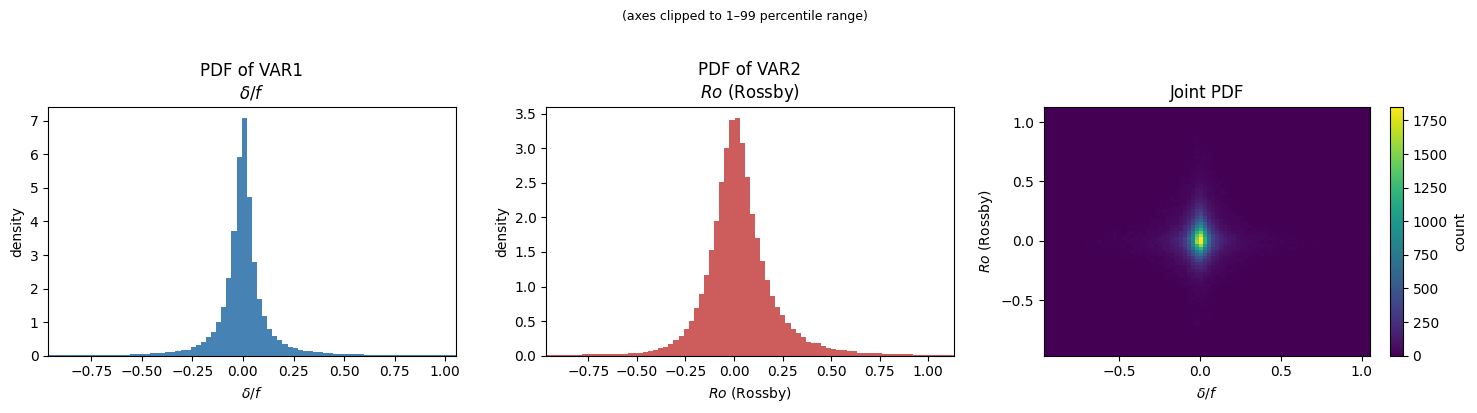

Selected-variable summary:
  VAR1 ($\delta / f$): n=111,293  median=-0.0004886  range=[-41.48, 27.4]  p2=-0.5219  p98=0.5492
  VAR2 ($Ro$ (Rossby)): n=111,833  median=0.01408  range=[-506.8, 518.2]  p2=-0.481  p98=0.665


In [60]:
import matplotlib.pyplot as plt


def summarize_selection(v1, v2, label1, label2, bins=80, robust_pct=1):
    """PDF of v1, PDF of v2, joint PDF, and printed median / range.

    Axis limits are clipped to the [robust_pct, 100-robust_pct] percentile range
    so a few extreme outliers don't squash the visible distribution. Set
    robust_pct=0 to show the full data range.
    """
    v1 = np.asarray(v1, dtype=np.float64)
    v2 = np.asarray(v2, dtype=np.float64)
    m1 = np.isfinite(v1)
    m2 = np.isfinite(v2)
    both = m1 & m2

    def _lims(v, mask):
        vv = v[mask]
        if robust_pct and robust_pct > 0:
            return float(np.percentile(vv, robust_pct)), float(np.percentile(vv, 100 - robust_pct))
        return float(vv.min()), float(vv.max())

    lim1 = _lims(v1, m1)
    lim2 = _lims(v2, m2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(v1[m1], bins=bins, range=lim1, density=True, color='steelblue')
    axes[0].set_xlim(lim1)
    axes[0].set_title(f"PDF of VAR1\n{label1}")
    axes[0].set_xlabel(label1); axes[0].set_ylabel("density")

    axes[1].hist(v2[m2], bins=bins, range=lim2, density=True, color='indianred')
    axes[1].set_xlim(lim2)
    axes[1].set_title(f"PDF of VAR2\n{label2}")
    axes[1].set_xlabel(label2); axes[1].set_ylabel("density")

    h = axes[2].hist2d(v1[both], v2[both], bins=bins, range=[lim1, lim2], cmap='viridis')
    fig.colorbar(h[3], ax=axes[2], label="count")
    axes[2].set_title("Joint PDF")
    axes[2].set_xlabel(label1); axes[2].set_ylabel(label2)

    if robust_pct and robust_pct > 0:
        fig.suptitle(f"(axes clipped to {robust_pct}–{100 - robust_pct} percentile range)",
                     fontsize=9, y=1.02)
    fig.tight_layout()
    plt.show()

    def _stats(name, v, mask):
        vv = v[mask]
        print(f"  {name}: n={vv.size:,}  median={np.median(vv):.4g}  "
              f"range=[{vv.min():.4g}, {vv.max():.4g}]  "
              f"p2={np.percentile(vv, 2):.4g}  p98={np.percentile(vv, 98):.4g}")

    print("Selected-variable summary:")
    _stats(f"VAR1 ({label1})", v1, m1)
    _stats(f"VAR2 ({label2})", v2, m2)
    return fig


_ = summarize_selection(values1, values2, VAR1_LABEL, VAR2_LABEL)

---
## 5. Plot Configuration

**Bin ranges** — two modes:

- `BIN_RANGE_MODE = "manual"`: use the `VAR*_MIN` / `VAR*_MAX` (and optional
  `VAR*_CENTER`) values below.
- `BIN_RANGE_MODE = "data"`: derive the range from the selected data. Set
  `DATA_RANGE_ROBUST_PCT = 0` for the full min/max, or e.g. `2` for a robust
  (2nd-98th percentile) range.

A non-`None` `*_CENTER` makes the bins symmetric about that value — handy for a
diverging variable centred on zero.

**Color modes** — two modes:

- `COLOR_MODE = "manual"`: you specify every legend color in `MANUAL_COLORS`
  (shape `(N_BINS_Y, N_BINS_X, 3)`, row 0 = lowest VAR2).
- `COLOR_MODE = "colormap"`: the VAR1 (x) axis uses a diverging `cmocean`
  colormap (`CMOCEAN_CMAP`); the VAR2 (y) axis lightens/darkens those colors.

In [61]:
# ─── BINS ─────────────────────────────────────────────────────────────────────
N_BINS_X = 2     # VAR1 bins
N_BINS_Y = 2     # VAR2 bins

# ─── BIN RANGES ───────────────────────────────────────────────────────────────
BIN_RANGE_MODE = "data"     # "manual" or "data"

# (a) manual range — used when BIN_RANGE_MODE == "manual"
VAR1_MIN, VAR1_MAX, VAR1_CENTER = -0.5,  0.5,  0.0   # CENTER=None to disable
VAR2_MIN, VAR2_MAX, VAR2_CENTER = -0.5,  0.5,  0.0

# (b) data-driven range — used when BIN_RANGE_MODE == "data"
DATA_RANGE_ROBUST_PCT = 2     # 0 = full min/max; >0 = robust [p, 100-p] range

# ─── COLORS ───────────────────────────────────────────────────────────────────
COLOR_MODE   = "colormap"     # "colormap" or "manual"
CMOCEAN_CMAP = "balance"      # diverging cmocean map for the VAR1 (x) axis
LIGHTNESS    = (1.25, 0.7)   # (top-row factor, bottom-row factor): >1 lighten, <1 darken

# Manual legend colors — used when COLOR_MODE == "manual".
# Shape (N_BINS_Y, N_BINS_X, 3); row 0 = lowest VAR2, col 0 = lowest VAR1.
MANUAL_COLORS = [
    [[0.87, 0.87, 0.87], [0.55, 0.62, 0.80], [0.24, 0.31, 0.71]],  # low  VAR2
    [[0.83, 0.55, 0.45], [0.55, 0.45, 0.55], [0.30, 0.30, 0.60]],  # mid  VAR2
    [[0.83, 0.24, 0.30], [0.55, 0.20, 0.38], [0.33, 0.15, 0.46]],  # high VAR2
]

### Binning + colormap helpers

(Kept separate from the configuration above so they rarely need editing.)

In [62]:
import matplotlib.colors as mcolors


def compute_bin_edges(n_bins, vmin, vmax, center=None):
    """Bin edges over [vmin, vmax]; if `center` is given, make them symmetric
    about `center` (half-width = max distance to either end)."""
    if center is None:
        return np.linspace(vmin, vmax, n_bins + 1)
    half = max(center - vmin, vmax - center)
    return np.linspace(center - half, center + half, n_bins + 1)


def data_range(values, robust_pct=0):
    """(min, max) of finite `values`, or the robust [p, 100-p] range."""
    v = np.asarray(values, dtype=np.float64)
    v = v[np.isfinite(v)]
    if robust_pct and robust_pct > 0:
        return np.percentile(v, robust_pct), np.percentile(v, 100 - robust_pct)
    return float(v.min()), float(v.max())


def assign_bins(values, edges):
    """Bin index (0-based) for each value; -1 where non-finite."""
    v = np.asarray(values, dtype=np.float64)
    n = len(edges) - 1
    idx = np.clip(np.digitize(v, edges) - 1, 0, n - 1).astype(int)
    idx[~np.isfinite(v)] = -1
    return idx


def make_colormap(n_x, n_y, mode="colormap", cmap_name="balance",
                  manual_colors=None, lightness=(1.25, 0.55)):
    """Build the (n_y, n_x, 3) bivariate color grid.

    grid[i, j] = color for (VAR2 bin i, VAR1 bin j); i=0 is the lowest VAR2.

    mode="manual"   : grid is `manual_colors` (shape (n_y, n_x, 3)).
    mode="colormap" : VAR1 axis sampled from a diverging cmocean map; VAR2 axis
                      lightens/darkens (factor > 1 lighten, < 1 darken).
    """
    if mode == "manual":
        grid = np.asarray(manual_colors, dtype=np.float64)
        if grid.shape != (n_y, n_x, 3):
            raise ValueError(
                f"MANUAL_COLORS must have shape ({n_y}, {n_x}, 3); got {grid.shape}."
            )
        return np.clip(grid, 0, 1)

    if mode == "colormap":
        import cmocean
        cmap = getattr(cmocean.cm, cmap_name)
        xs = np.linspace(0, 1, n_x) if n_x > 1 else np.array([0.5])
        x_colors = np.asarray(cmap(xs))[:, :3]
        facs = np.linspace(lightness[0], lightness[1], n_y) if n_y > 1 else np.array([1.0])
        grid = np.zeros((n_y, n_x, 3))
        for i, f in enumerate(facs):
            if f >= 1.0:   # lighten toward white
                grid[i] = x_colors + (1.0 - x_colors) * (f - 1.0)
            else:          # darken toward black
                grid[i] = x_colors * f
        return np.clip(grid, 0, 1)

    raise ValueError(f"Unknown COLOR_MODE {mode!r} (use 'manual' or 'colormap').")

### Resolve ranges, bins, and colors from the configuration

In [63]:
# ─── RESOLVE BIN RANGES ───────────────────────────────────────────────────────
if BIN_RANGE_MODE == "manual":
    v1_min, v1_max, v1_center = VAR1_MIN, VAR1_MAX, VAR1_CENTER
    v2_min, v2_max, v2_center = VAR2_MIN, VAR2_MAX, VAR2_CENTER
elif BIN_RANGE_MODE == "data":
    v1_min, v1_max = data_range(values1, DATA_RANGE_ROBUST_PCT)
    v2_min, v2_max = data_range(values2, DATA_RANGE_ROBUST_PCT)
    v1_center = v2_center = None
else:
    raise ValueError(f"Unknown BIN_RANGE_MODE {BIN_RANGE_MODE!r} (use 'manual' or 'data').")

edges1 = compute_bin_edges(N_BINS_X, v1_min, v1_max, v1_center)
edges2 = compute_bin_edges(N_BINS_Y, v2_min, v2_max, v2_center)

bins1 = assign_bins(values1, edges1)
bins2 = assign_bins(values2, edges2)

# ─── BUILD COLOR GRID ─────────────────────────────────────────────────────────
color_grid = make_colormap(
    N_BINS_X, N_BINS_Y,
    mode=COLOR_MODE, cmap_name=CMOCEAN_CMAP,
    manual_colors=MANUAL_COLORS, lightness=LIGHTNESS,
)

# ─── REPORT ───────────────────────────────────────────────────────────────────
valid_mask = (bins1 >= 0) & (bins2 >= 0)
print(f"Valid fronts (both variables finite & binned): {valid_mask.sum():,} / {len(bins1):,}")
print(f"VAR1 edges ({VAR1_LABEL}): {np.array2string(edges1, precision=4)}")
print(f"VAR2 edges ({VAR2_LABEL}): {np.array2string(edges2, precision=4)}")
print(f"\nBivariate bin counts ({N_BINS_Y} VAR2 rows x {N_BINS_X} VAR1 cols):")
for i in range(N_BINS_Y - 1, -1, -1):   # print high VAR2 at top
    row = " | ".join(f"{((bins1 == j) & (bins2 == i)).sum():6d}" for j in range(N_BINS_X))
    print(f"  VAR2 bin {i}: {row}")

Valid fronts (both variables finite & binned): 111,293 / 112,542
VAR1 edges ($\delta / f$): [-0.5219  0.0136  0.5492]
VAR2 edges ($Ro$ (Rossby)): [-0.481  0.092  0.665]

Bivariate bin counts (2 VAR2 rows x 2 VAR1 cols):
  VAR2 bin 1:  18782 |  12702
  VAR2 bin 0:  47861 |  31948


---
## 6. Plotting Functions

Three functions: the bivariate legend, the binned global map, and the scatter
global map. All major choices come from the configuration sections above.

In [64]:
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_bivariate_legend(color_grid, edges_x, edges_y,
                          label_x='VAR1', label_y='VAR2', figsize=(4.5, 4.5)):
    """Plot the 2-D bivariate legend (color_grid is (n_y, n_x, 3))."""
    n_y, n_x = color_grid.shape[:2]
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(n_y):        # VAR2 (rows, y)
        for j in range(n_x):    # VAR1 (cols, x)
            ax.add_patch(mpatches.FancyBboxPatch(
                (j, i), 1, 1, boxstyle='round,pad=0.02',
                facecolor=color_grid[i, j], edgecolor='white', linewidth=1.5,
            ))

    ax.set_xlim(0, n_x); ax.set_ylim(0, n_y); ax.set_aspect('equal')

    def _fmt(v):
        return f"{v:.1e}" if (abs(v) < 0.01 or abs(v) >= 1e4) else f"{v:.3g}"

    ax.set_xticks(np.arange(n_x + 1))
    ax.set_xticklabels([_fmt(e) for e in edges_x], fontsize=7, rotation=45, ha='right')
    ax.set_yticks(np.arange(n_y + 1))
    ax.set_yticklabels([_fmt(e) for e in edges_y], fontsize=7)

    ax.set_xlabel(f"{label_x}  →", fontsize=10, fontweight='bold')
    ax.set_ylabel(f"{label_y}  →", fontsize=10, fontweight='bold')
    ax.set_title('Bivariate Legend', fontsize=11)
    fig.tight_layout()
    return fig, ax


def _make_map_axes(projection, figsize):
    proj = {
        'Robinson':    ccrs.Robinson(),
        'Mollweide':   ccrs.Mollweide(),
        'PlateCarree': ccrs.PlateCarree(),
    }.get(projection, ccrs.Robinson())
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})
    ax.set_global()
    return fig, ax


def _add_map_features(ax):
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k',    zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.2, color='gray', zorder=3)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray',
                 alpha=0.5, linestyle='--')


def plot_global_scatter_map(df, bins1, bins2, color_grid,
                            label_x='VAR1', label_y='VAR2',
                            lat_col='centroid_lat', lon_col='centroid_lon',
                            projection='Robinson', marker_size=2.0,
                            title=None, figsize=(18, 9)):
    """Scatter every front centroid, colored by its (VAR1, VAR2) bin."""
    fig, ax = _make_map_axes(projection, figsize)
    tfm = ccrs.PlateCarree()

    valid = (bins1 >= 0) & (bins2 >= 0)
    lats = df[lat_col].values[valid]
    lons = df[lon_col].values[valid]
    front_colors = color_grid[bins2[valid], bins1[valid]]   # [VAR2 bin, VAR1 bin]

    ax.scatter(lons, lats, c=front_colors, s=marker_size, transform=tfm,
               zorder=1, rasterized=True, edgecolors='none')
    _add_map_features(ax)

    if title is None:
        title = (f'Bivariate Front Map (scatter): {label_x} × {label_y}\n'
                 f'({valid.sum():,} front centroids)')
    ax.set_title(title, fontsize=12, pad=10)
    fig.tight_layout()
    return fig, ax


def plot_global_binned_map(df, bins1, bins2, color_grid,
                           label_x='VAR1', label_y='VAR2',
                           lat_col='centroid_lat', lon_col='centroid_lon',
                           projection='Robinson', spatial_bin_deg=2,
                           title=None, figsize=(18, 9)):
    """Bin fronts into spatial_bin_deg cells; color each cell by its dominant
    (VAR1, VAR2) bivariate category."""
    fig, ax = _make_map_axes(projection, figsize)
    tfm = ccrs.PlateCarree()

    valid = (bins1 >= 0) & (bins2 >= 0)
    lats = df[lat_col].values[valid]
    lons = df[lon_col].values[valid]
    b1 = bins1[valid]
    b2 = bins2[valid]

    n_y, n_x = color_grid.shape[:2]
    biv_idx = b2 * n_x + b1                      # flatten (VAR2, VAR1) -> 1-D

    n_lat = int(180 / spatial_bin_deg)
    n_lon = int(360 / spatial_bin_deg)
    lat_edges = np.linspace(-90, 90, n_lat + 1)
    lon_edges = np.linspace(-180, 180, n_lon + 1)

    lat_idx = np.clip(np.digitize(lats, lat_edges) - 1, 0, n_lat - 1)
    lon_idx = np.clip(np.digitize(lons, lon_edges) - 1, 0, n_lon - 1)

    # Most-common bivariate category per spatial cell.
    n_cat = n_x * n_y
    cat_counts = np.zeros((n_lat, n_lon, n_cat), dtype=int)
    for li, lj, c in zip(lat_idx, lon_idx, biv_idx):
        cat_counts[li, lj, int(c)] += 1
    count_grid = cat_counts.sum(axis=2)
    mode_idx = np.argmax(cat_counts, axis=2)

    n_cells = 0
    for i in range(n_lat):
        for j in range(n_lon):
            if count_grid[i, j] == 0:
                continue
            cat = mode_idx[i, j]
            bj = cat % n_x        # VAR1 bin
            bi = cat // n_x       # VAR2 bin
            ax.fill_between([lon_edges[j], lon_edges[j + 1]],
                            lat_edges[i], lat_edges[i + 1],
                            color=color_grid[bi, bj], transform=tfm, zorder=1)
            n_cells += 1

    _add_map_features(ax)
    if title is None:
        title = (f'Bivariate Front Map (binned): {label_x} × {label_y}\n'
                 f'({n_cells:,} cells, {spatial_bin_deg}° bins, mode category)')
    ax.set_title(title, fontsize=12, pad=10)
    fig.tight_layout()
    return fig, ax

### Generate the plots

Everything comes from the configuration sections above. Edit §4 (variables /
depth / statistic) and §5 (bins / ranges / colors), then re-run.

In [65]:
# ─── MAP / OUTPUT OPTIONS ─────────────────────────────────────────────────────
PROJECTION      = 'Robinson'   # 'Robinson', 'Mollweide', 'PlateCarree'
SPATIAL_BIN_DEG = 2            # cell size for the binned map (degrees)
MARKER_SIZE     = 5.0          # marker size for the scatter map

SAVE_DIR = Path('.') / 'figures'
SAVE_DPI = 200

_tag = f"{VAR1}_x_{VAR2}_{DEPTH_LEVEL}_{SUMMARY_STATISTIC}_{N_BINS_X}x{N_BINS_Y}"

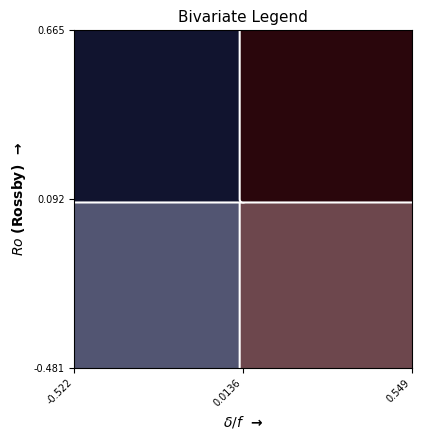

In [66]:
# ─── PLOT 1: BIVARIATE LEGEND ─────────────────────────────────────────────────
fig_legend, _ = plot_bivariate_legend(
    color_grid, edges1, edges2, label_x=VAR1_LABEL, label_y=VAR2_LABEL,
)
plt.show()

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


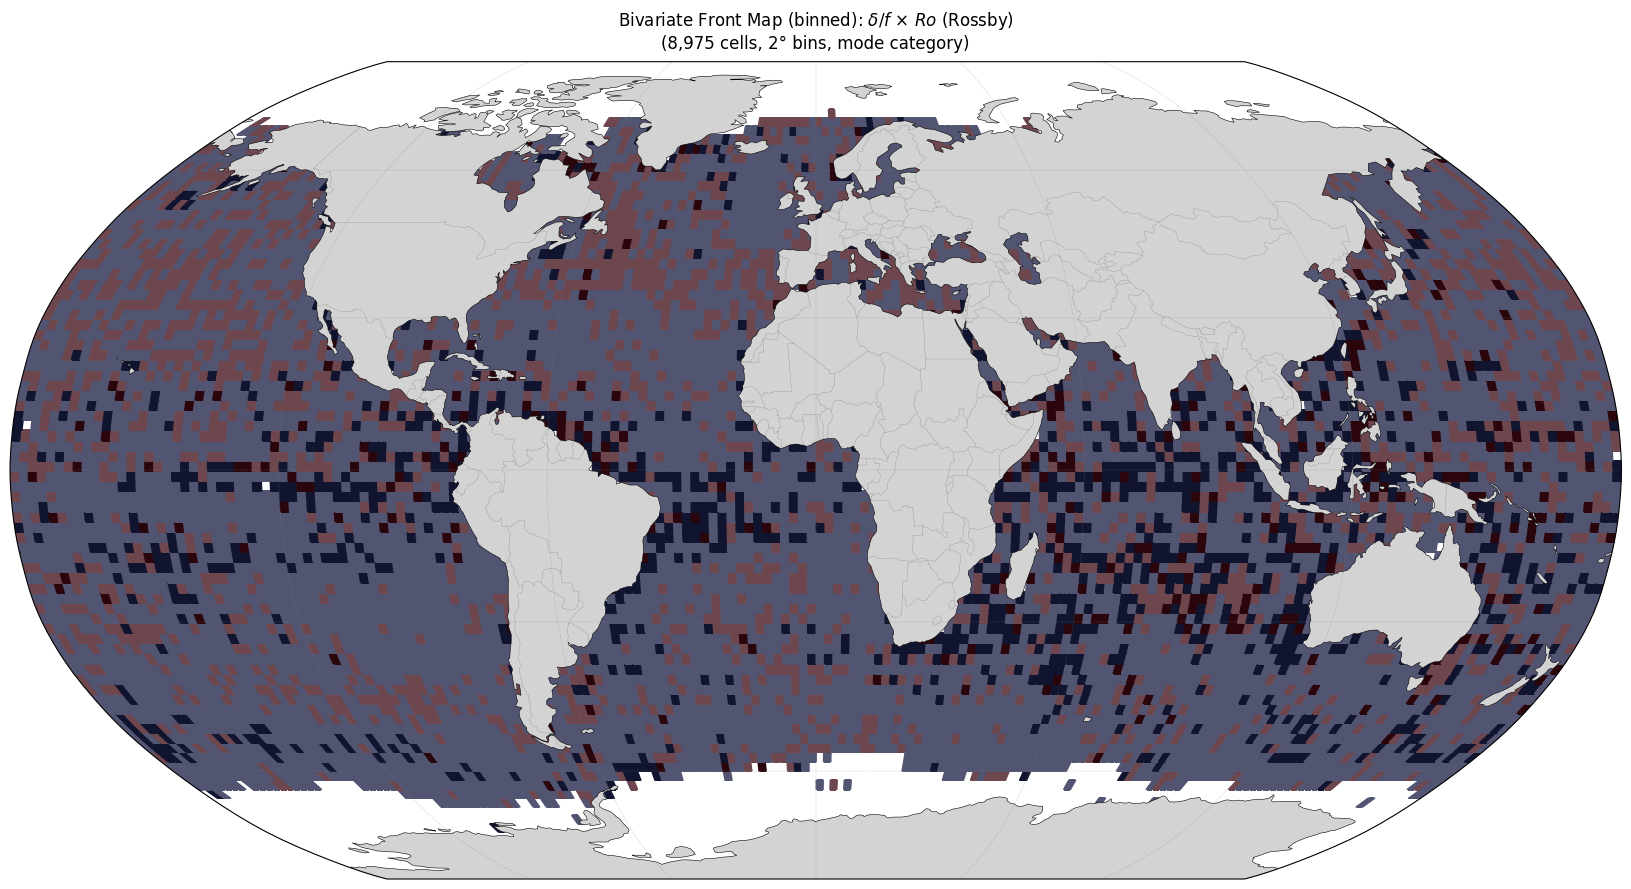

In [67]:
# ─── PLOT 2: GLOBAL MAP (BINNED) ──────────────────────────────────────────────
fig_binned, _ = plot_global_binned_map(
    df_enriched, bins1, bins2, color_grid,
    label_x=VAR1_LABEL, label_y=VAR2_LABEL,
    projection=PROJECTION, spatial_bin_deg=SPATIAL_BIN_DEG,
)
plt.show()

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


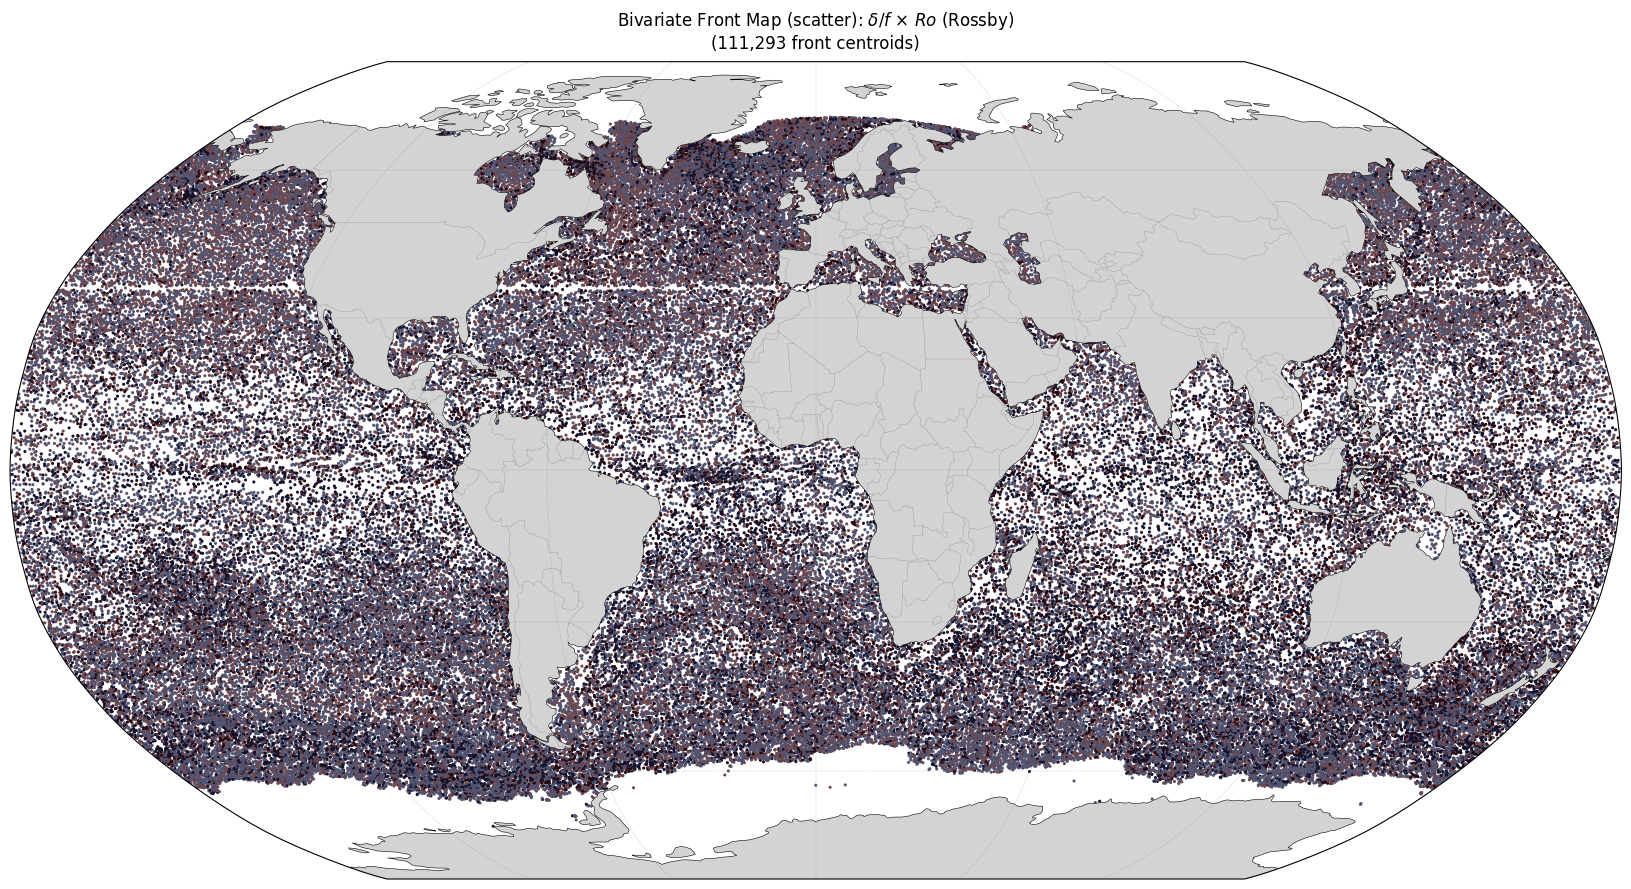

In [68]:
# ─── PLOT 3: GLOBAL MAP (SCATTER) ─────────────────────────────────────────────
fig_scatter, _ = plot_global_scatter_map(
    df_enriched, bins1, bins2, color_grid,
    label_x=VAR1_LABEL, label_y=VAR2_LABEL,
    projection=PROJECTION, marker_size=MARKER_SIZE,
)
plt.show()

In [ ]:
# ─── SAVE FIGURES (optional) ──────────────────────────────────────────────────
SAVE_DIR.mkdir(parents=True, exist_ok=True)
fig_legend.savefig(SAVE_DIR / f"bivariate_legend_{_tag}.png",
                   dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
fig_binned.savefig(SAVE_DIR / f"bivariate_binned_{_tag}.png",
                   dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
fig_scatter.savefig(SAVE_DIR / f"bivariate_scatter_{_tag}.png",
                    dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
print(f"Saved figures to {SAVE_DIR.resolve()} with tag {_tag!r}")